<a href="https://colab.research.google.com/github/BernardoBib/Conversao-Eletromecanica-Python/blob/main/Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Característica Real do Núcleo

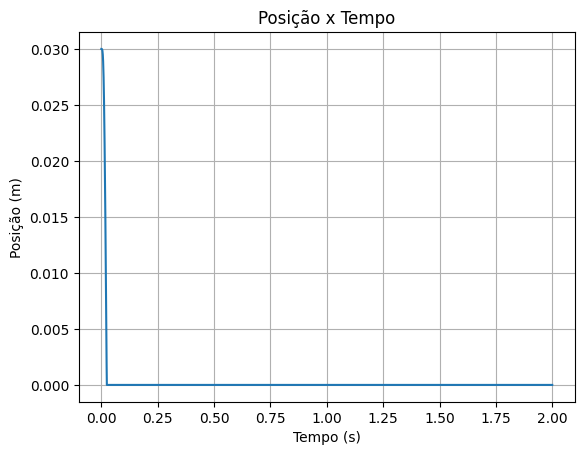

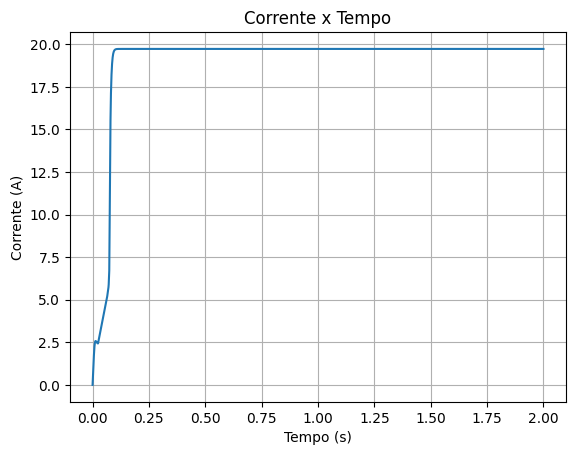

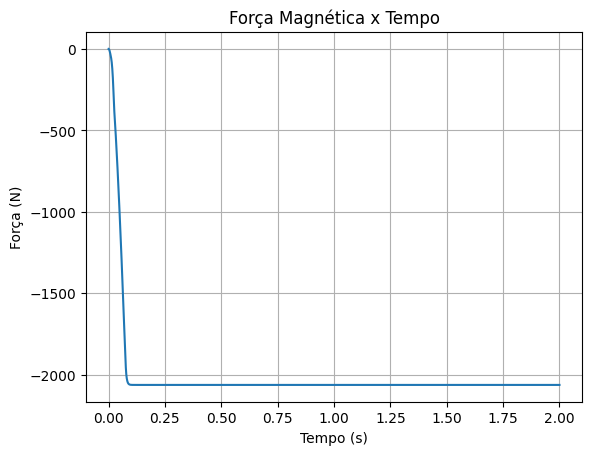

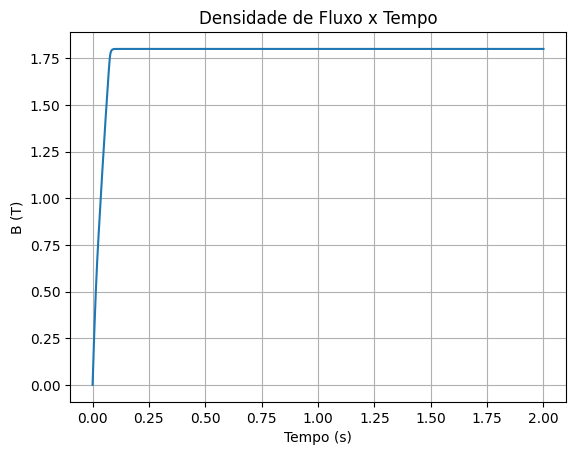

╭────────────────────────────────────────────── Energia do Impacto ───────────────────────────────────────────────╮
│ k = 100 N/m                                                                                                     │
│                                                                                                                 │
│ Energia cinética: 0.321580 J                                                                                    │
│ Energia magnética: 1.484160 J                                                                                   │
│ Energia no resistor: 0.233090 J                                                                                 │
│ Energia total: 2.038830 J                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── Energia do Impacto ───────────────────────────────────────────────╮
│ k = 1000 N/m                                                                                                    │
│                                                                                                                 │
│ Energia cinética: 0.720683 J                                                                                    │
│ Energia magnética: 1.252627 J                                                                                   │
│ Energia no resistor: 0.192527 J                                                                                 │
│ Energia total: 2.165837 J                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
!pip install rich

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from rich.console import Console
from rich.panel import Panel

# ================================
# DADOS B x H
# ================================
H_d = np.array([0,68,135,203,271,338,406,474,542,609,1100,1500,2500,4000,5000,9000,12000,20000,25000],dtype=float)
B_d = np.array([0,0.733,1.205,1.424,1.517,1.560,1.588,1.617,1.631,1.646,1.689,1.703,1.724,1.731,1.738,1.761,1.770,1.80,1.816],dtype=float)

f_H = interp1d(B_d,H_d,kind='cubic',bounds_error=False,fill_value=(H_d[0],H_d[-1]))

# ================================
# PARÂMETROS
# ================================
u0 = 4*np.pi*1e-7
N = 1000
g = 0.002
l = 0.04
lc = 0.70
d = 0.04
m = 0.1
R = 2
V = 39.46
x0 = 0.03
xm = 0
lg = 2*g
bt = 0.5

# ================================
# GEOMETRIA
# ================================
def f_Ag(x):
    xs = np.clip(x,1e-6,d*0.999)
    return l*(d-xs)

def f_An(x):
    xs = np.maximum(xm,x)
    return l*(d-bt*xs)

# ================================
# COENERGIA
# ================================
def f_W(B,x):

    Bv = np.linspace(0,B,100)
    Hv = f_H(Bv)

    An_x = f_An(x)
    Ag_x = f_Ag(x)

    iv = (Hv*lc + (Bv*An_x*lg)/(u0*Ag_x))/N

    return np.trapezoid(iv*N*An_x,Bv)

# ================================
# SIMULAÇÃO
# ================================
def rodar(k):

    def f_sis(t,y):

        B,x,v = y

        H = float(f_H(B))

        An_x = f_An(x)
        Ag_x = f_Ag(x)

        i = (H*lc + (B*An_x*lg)/(u0*Ag_x))/N

        h = 1e-5

        Wp = f_W(B,x+h)
        Wm = f_W(B,x-h)

        Fm = -(Wp-Wm)/(2*h)

        Fe = -k*(x-x0)

        dB = (V-R*i)/(N*An_x)
        dx = v
        dv = (Fm-Fe)/m

        return [dB,dx,dv]

    sol = solve_ivp(
        f_sis,
        [0,2],
        [0,x0,0],
        method='Radau',
        t_eval=np.linspace(0,2,4000),
        rtol=1e-7,
        atol=1e-9
    )

    B_s,x_s,v_s = sol.y

    idx = np.where(x_s<=xm)[0][0]

    i_s = np.zeros_like(B_s)
    Fmag = np.zeros_like(B_s)

    h = 1e-5

    for k in range(len(B_s)):

        Wp = f_W(B_s[k],x_s[k]+h)
        Wm = f_W(B_s[k],x_s[k]-h)

        Fn = (Wp-Wm)/(2*h)

        Fg = (B_s[k]**2*f_Ag(x_s[k]))/(2*u0)

        Fmag[k] = -Fg-Fn

        H = float(f_H(B_s[k]))

        i_s[k] = (H*lc + (B_s[k]*f_An(x_s[k])*lg)/(u0*f_Ag(x_s[k])))/N

    Ec = 0.5*m*v_s[idx]**2
    Em = f_W(B_s[idx],x_s[idx])
    Er = np.trapezoid(i_s[:idx+1]**2*R,sol.t[:idx+1])

    Et = Ec+Em+Er

    return sol,x_s,i_s,B_s,Fmag,Ec,Em,Er,Et,idx

# ================================
# RESULTADOS
# ================================
cons = Console()
resultados = []

for kv in [100,1000]:

    sol,x_v,i_v,B_v,F_v,Ec,Em,Er,Et,idx = rodar(kv)

    x_v[idx:] = xm

    txt = (
        f"k = {kv} N/m\n\n"
        f"Energia cinética: {Ec:.6f} J\n"
        f"Energia magnética: {Em:.6f} J\n"
        f"Energia no resistor: {Er:.6f} J\n"
        f"[bold red]Energia total: {Et:.6f} J[/bold red]"
    )

    resultados.append(txt)

    if kv == 100:

        plt.figure()
        plt.plot(sol.t,x_v)
        plt.title("Posição x Tempo")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Posição (m)")
        plt.grid()

        plt.figure()
        plt.plot(sol.t,i_v)
        plt.title("Corrente x Tempo")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Corrente (A)")
        plt.grid()

        plt.figure()
        plt.plot(sol.t,F_v)
        plt.title("Força Magnética x Tempo")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Força (N)")
        plt.grid()

        plt.figure()
        plt.plot(sol.t,B_v)
        plt.title("Densidade de Fluxo x Tempo")
        plt.xlabel("Tempo (s)")
        plt.ylabel("B (T)")
        plt.grid()

        plt.show()

# ================================
# MOSTRAR ENERGIAS
# ================================
for txt in resultados:
    cons.print(Panel(txt,title="Energia do Impacto"))

t_real = sol.t
x_real = x_v
i_real = i_v
B_real = B_v
Fm_real = F_v

# Aproximação Linear

O valor de Mi relativo é: 832.92
Solver OK? True
The solver successfully reached the end of the integration interval.


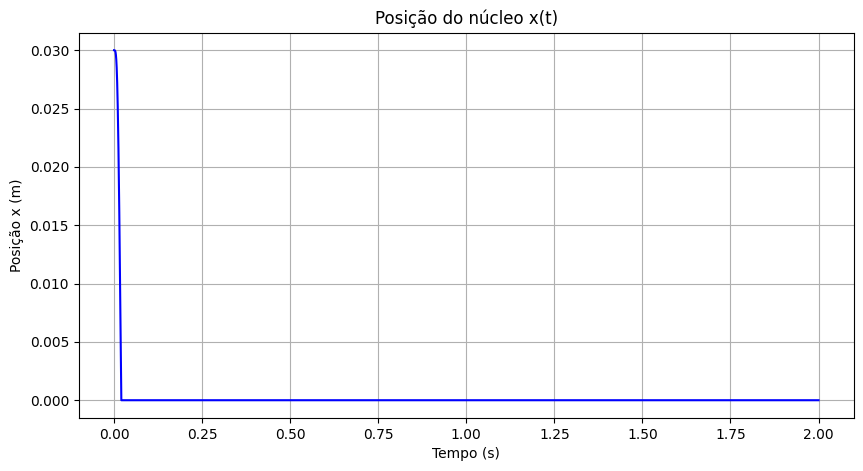

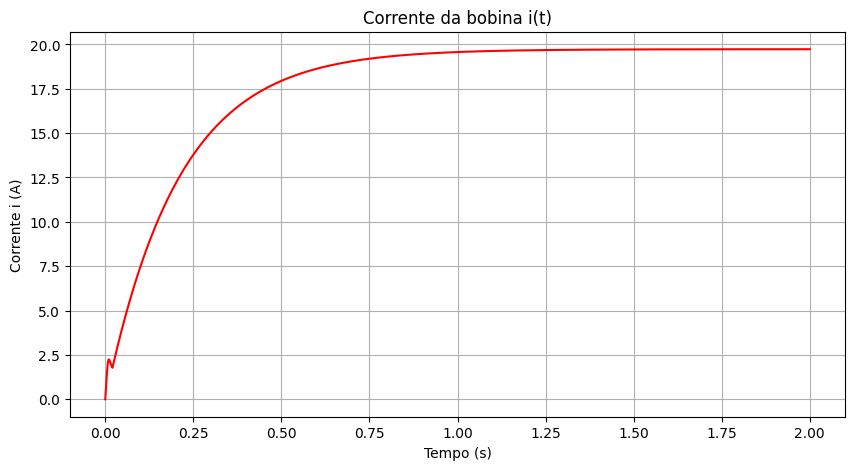

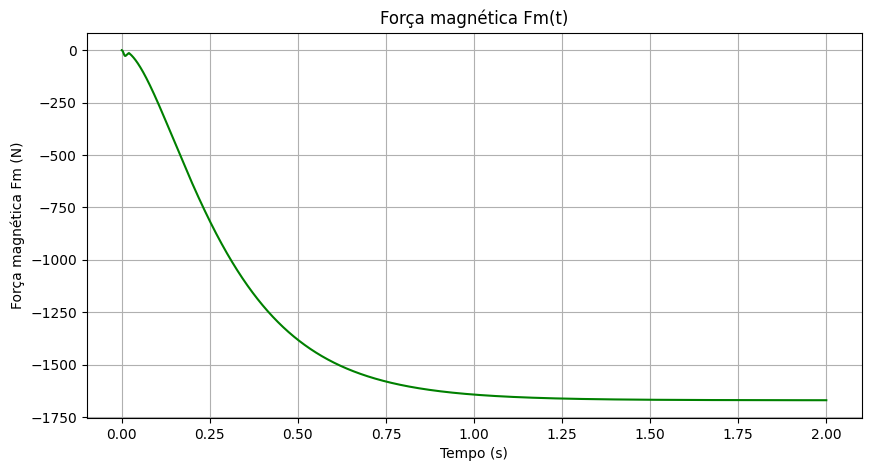

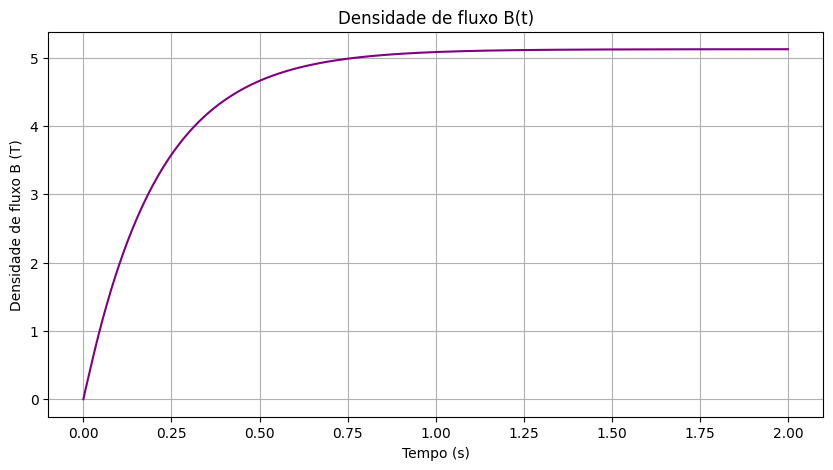

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

#=======================================================
# Dados da tabela (H em A/m, B em T)

H = np.array([
    0, 68, 135, 203, 271, 338, 406, 474, 542, 609,
    1100, 1500, 2500, 4000, 5000, 9000, 12000, 20000, 25000
])

B = np.array([
    0, 0.733, 1.205, 1.424, 1.517, 1.560, 1.588, 1.617, 1.631, 1.646,
    1.689, 1.703, 1.724, 1.731, 1.738, 1.761, 1.770, 1.800, 1.816
])

# Interpolação (mantida apenas para referência dos dados)
interp_func = interp1d(H, B, kind='cubic')

# Pontos escolhidos da região linear
H1 = 135
B1 = 1.205
H2 = 542
B2 = 1.631

U0 = 4*np.pi*(10**-7)

Ueq = (B2-B1)/(H2-H1)
Urel = Ueq/U0

print("O valor de Mi relativo é: %.2f" % Urel)

# ==============================
# PARÂMETROS
# ==============================

μ0 = 4*np.pi*1e-7
N = 1000
g = 0.002
l = 0.04
lc = 0.70
d = 0.04
m = 0.1
k = 100
R = 2
V = 39.46
x0 = 0.03
x_min = 0.0
Mr = Urel

# ==============================
# RELUTÂNCIAS E INDUTÂNCIA
# ==============================

Rn = lc / (Mr * μ0 * l * d)

def Rg(x):
    x_safe = np.minimum(x, d*0.999)
    return 2 * g / (μ0 * l * (d - x_safe))

def L(x):
    return (N**2) / (Rn + Rg(x))

def dLdx(x):
    x_safe = np.minimum(x, d*0.999)

    A = l * (d - x_safe)
    Rg_val = 2*g/(μ0*A)

    dRg_dx = 2*g/(μ0*l*(d - x_safe)**2)

    return -N**2 * dRg_dx / (Rn + Rg_val)**2

# ==============================
# SISTEMA DE EDO
# ==============================

def sistema(t, X):
    x, v, i = X

    if x <= x_min:
        x = x_min
        v = 0.0

    Fm = 0.5 * i**2 * dLdx(x)
    Fel = k * (x - x0)

    dxdt = v
    dvdt = (Fm - Fel) / m
    didt = (V - R*i - i*dLdx(x)*v) / L(x)

    return [dxdt, dvdt, didt]

# ==============================
# CONDIÇÕES INICIAIS
# ==============================

X0 = [x0, 0.0, 0.0]

# ==============================
# SIMULAÇÃO
# ==============================

t_final = 2
t_eval = np.linspace(0, t_final, 10000)

sol = solve_ivp(
    sistema,
    (0, t_final),
    X0,
    t_eval=t_eval,
    method="Radau",
    rtol=1e-6,
    atol=1e-9
)

print("Solver OK?", sol.success)
print(sol.message)

# ==============================
# RESULTADOS
# ==============================

t = sol.t
x = sol.y[0]
v = sol.y[1]
i = sol.y[2]

Fm = 0.5 * i**2 * dLdx(x)
B_vals = N * i / ((Rn + Rg(x)) * l * d)

# ==============================
# GRÁFICOS
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(t, x, color='blue')
plt.xlabel("Tempo (s)")
plt.ylabel("Posição x (m)")
plt.title("Posição do núcleo x(t)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, i, color='red')
plt.xlabel("Tempo (s)")
plt.ylabel("Corrente i (A)")
plt.title("Corrente da bobina i(t)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, Fm, color='green')
plt.xlabel("Tempo (s)")
plt.ylabel("Força magnética Fm (N)")
plt.title("Força magnética Fm(t)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, B_vals, color='purple')
plt.xlabel("Tempo (s)")
plt.ylabel("Densidade de fluxo B (T)")
plt.title("Densidade de fluxo B(t)")
plt.grid(True)
plt.show()

t_linear = t
x_linear = x
i_linear = i
B_linear = B_vals
Fm_linear = Fm

# Considerando Ideal

Solver OK? True
The solver successfully reached the end of the integration interval.


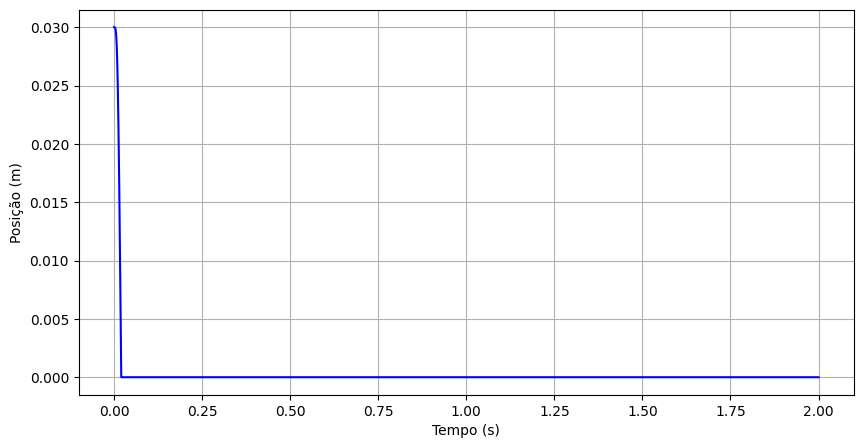

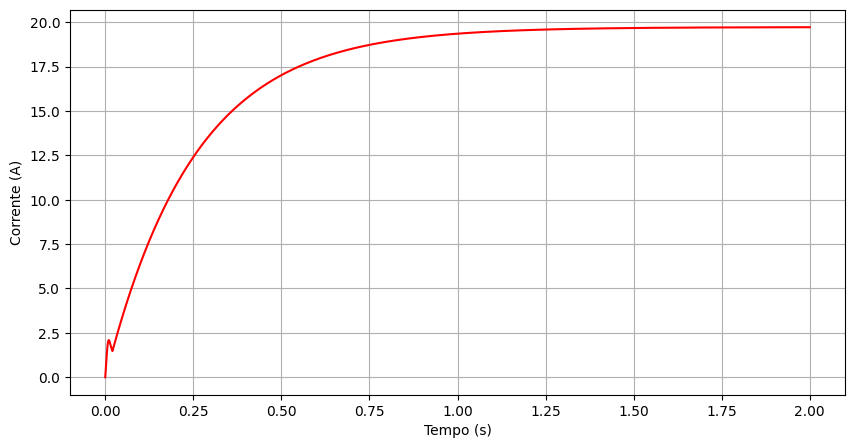

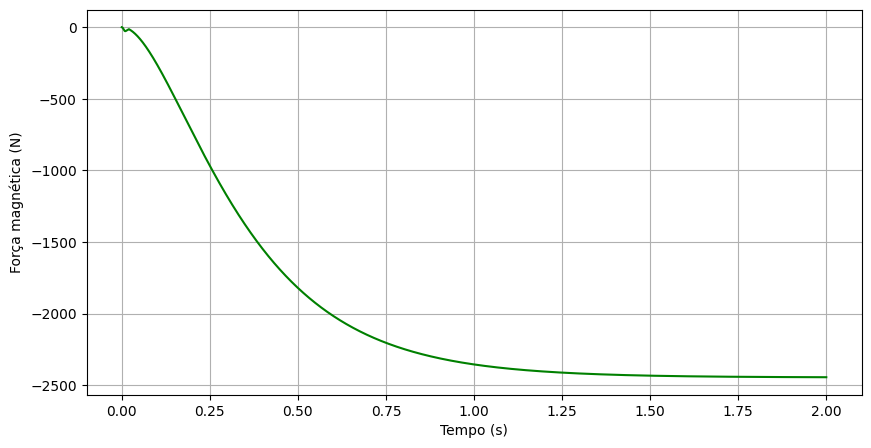

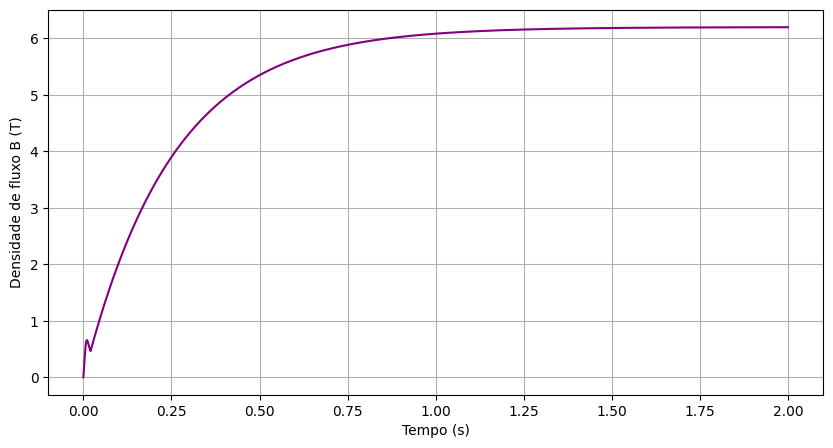

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==============================
# PARÂMETROS

μ0 = 4*np.pi*1e-7
N = 1000
g = 0.002          # entreferro (m)
l = 0.04           # Espessura (m)
d = 0.04           # Largura (m)
m = 0.1            # Massa em (Kg)
k = 100            # Constante da Mola (N/m)
R = 2              # Resistencia (Ohms)
V = 39.46           # Tensão constante (V)
x0 = 0.03          # posição inicial (m)
x_min = 0.0        # posição final (m)

# ==============================
#Calculos para o núcleo como um meio magnético ideal:

def L(x):
    return (μ0 * N**2 * l * (d - x)) / (2*g) # Indutância

dLdx = - μ0 * N**2 * l / (2*g)   # Derivada da indutância



# ==============================
#Sistema de EDO:

def sistema(t, X):
    x, v, i = X # posição, velocidade e corrente

    # Posição final
    if x <= x_min:
        x = x_min
        v = 0.0

    Fm = 0.5 * i**2 * dLdx # Força magnética

    Fel = k * (x - x0) # Força elástica

    dxdt = v

    dvdt = (Fm - Fel) / m

    didt = (V - R*i - i*dLdx*v) / L(x)

    return [dxdt, dvdt, didt]

# ==============================
# CONDIÇÕES INICIAIS

X0 = [x0, 0.0, 0.0] # posição, velocidade , corrente

# ==============================
# SIMULAÇÃO

t_final = 2
t_eval = np.linspace(0, t_final, 10000)

sol = solve_ivp(
    sistema,
    (0, t_final),
    X0,
    t_eval=t_eval,
    method="Radau",
    rtol=1e-6,
    atol=1e-9
)

print("Solver OK?", sol.success)
print(sol.message)

# ==============================
# RESULTADOS
# ==============================

t = sol.t
x = sol.y[0]
v = sol.y[1]
i = sol.y[2]

Fm = 0.5 * i**2 * dLdx #Força magnética
B = μ0 * N * i / (2*g) # Densidade de fluxo

# ==============================
# GRÁFICOS
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(t, x, color='blue')
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (m)")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, i,color='red')
plt.xlabel("Tempo (s)")
plt.ylabel("Corrente (A)")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, Fm, color='green')
plt.xlabel("Tempo (s)")
plt.ylabel("Força magnética (N)")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, B, color='purple')
plt.xlabel("Tempo (s)")
plt.ylabel("Densidade de fluxo B (T)")
plt.grid()
plt.show()

t_ideal = t
x_ideal = x
i_ideal = i
B_ideal = B
Fm_ideal = Fm


# Sobreposição Dos Três Modelos

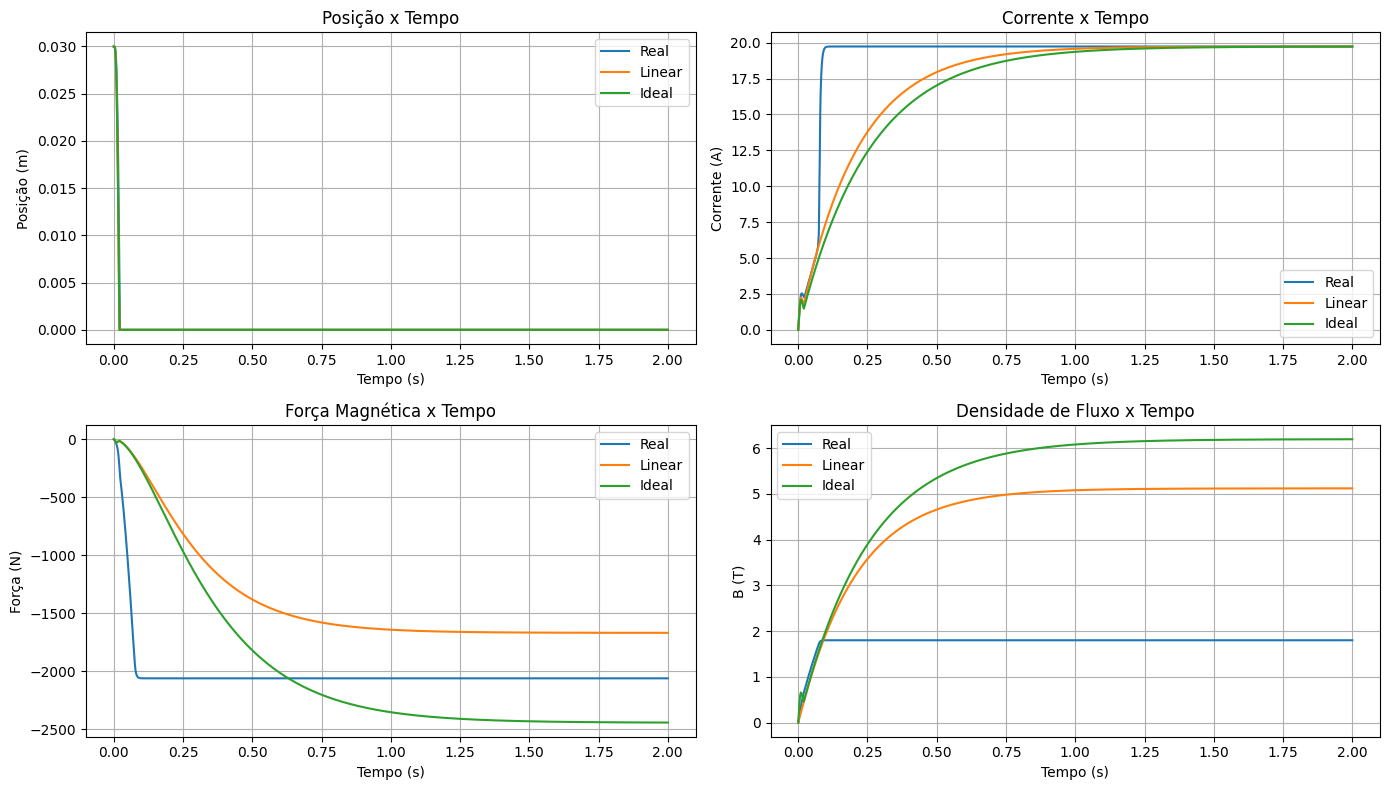

╭────── Energia do Impacto ───────╮ ╭────── Energia do Impacto ───────╮
│ k = 100 N/m                     │ │ k = 1000 N/m                    │
│                                 │ │                                 │
│ Energia cinética: 0.321580 J    │ │ Energia cinética: 0.720683 J    │
│ Energia magnética: 1.484160 J   │ │ Energia magnética: 1.252627 J   │
│ Energia no resistor: 0.233090 J │ │ Energia no resistor: 0.192527 J │
│ Energia total: 2.038830 J       │ │ Energia total: 2.165837 J       │
╰─────────────────────────────────╯ ╰─────────────────────────────────╯

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# GRÁFICOS COMPARATIVOS (2x2)
# ===============================

fig, ax = plt.subplots(2,2, figsize=(14,8))

# POSIÇÃO
ax[0,0].plot(t_real, x_real, label="Real")
ax[0,0].plot(t_linear, x_linear, label="Linear")
ax[0,0].plot(t_ideal, x_ideal, label="Ideal")
ax[0,0].set_title("Posição x Tempo")
ax[0,0].set_xlabel("Tempo (s)")
ax[0,0].set_ylabel("Posição (m)")
ax[0,0].grid()
ax[0,0].legend()

# CORRENTE
ax[0,1].plot(t_real, i_real, label="Real")
ax[0,1].plot(t_linear, i_linear, label="Linear")
ax[0,1].plot(t_ideal, i_ideal, label="Ideal")
ax[0,1].set_title("Corrente x Tempo")
ax[0,1].set_xlabel("Tempo (s)")
ax[0,1].set_ylabel("Corrente (A)")
ax[0,1].grid()
ax[0,1].legend()

# FORÇA MAGNÉTICA
ax[1,0].plot(t_real, Fm_real, label="Real")
ax[1,0].plot(t_linear, Fm_linear, label="Linear")
ax[1,0].plot(t_ideal, Fm_ideal, label="Ideal")
ax[1,0].set_title("Força Magnética x Tempo")
ax[1,0].set_xlabel("Tempo (s)")
ax[1,0].set_ylabel("Força (N)")
ax[1,0].grid()
ax[1,0].legend()

# DENSIDADE DE FLUXO
ax[1,1].plot(t_real, B_real, label="Real")
ax[1,1].plot(t_linear, B_linear, label="Linear")
ax[1,1].plot(t_ideal, B_ideal, label="Ideal")
ax[1,1].set_title("Densidade de Fluxo x Tempo")
ax[1,1].set_xlabel("Tempo (s)")
ax[1,1].set_ylabel("B (T)")
ax[1,1].grid()
ax[1,1].legend()

plt.tight_layout()
plt.show()


# ===============================
# MOSTRAR ENERGIAS (k = 100 e 1000)
# ===============================

from rich.console import Console
from rich.panel import Panel
from rich.columns import Columns

cons = Console()

paineis = []

for txt in resultados:
    paineis.append(Panel(txt, title="Energia do Impacto"))

cons.print(Columns(paineis))